# Explore here

In [68]:
#Los IMPORTS
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs
from mpl_toolkits.mplot3d import Axes3D
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier

from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN

from sklearn.metrics import silhouette_score

from sklearn.datasets import load_iris
from sklearn.decomposition import PCA

import joblib
import warnings
warnings.filterwarnings('ignore')


In [49]:
#Cargamos CSV
url = "https://breathecode.herokuapp.com/asset/internal-link?id=809&path=housing.csv"
pd.read_csv(url).to_csv("../data/raw/housing.csv", index=False)

In [50]:
df = pd.read_csv("../data/raw/housing.csv")
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [51]:
#Dimensiones del DataFrame
df.shape

(20640, 9)

In [52]:
#Resumen completo del DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [53]:
#Mostrar resumen estadístico básico del dataset
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [54]:
#Comprobación de nulos
print(df.isnull().sum())

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [55]:
#Mostrar duplicados del dataset
duplicados = df.duplicated()
num_duplicados = duplicados.sum()

print(f"Hay un total de {num_duplicados} duplicados en el Dataset")

Hay un total de 0 duplicados en el Dataset


In [56]:
#Seleccionamos columanas del dataset
df = df[["Latitude", "Longitude", "MedInc"]]
df.head()

,Latitude,Longitude,MedInc
0,37.88,-122.23,8.3252
1,37.86,-122.22,8.3014
2,37.85,-122.24,7.2574
3,37.85,-122.25,5.6431
4,37.85,-122.25,3.8462


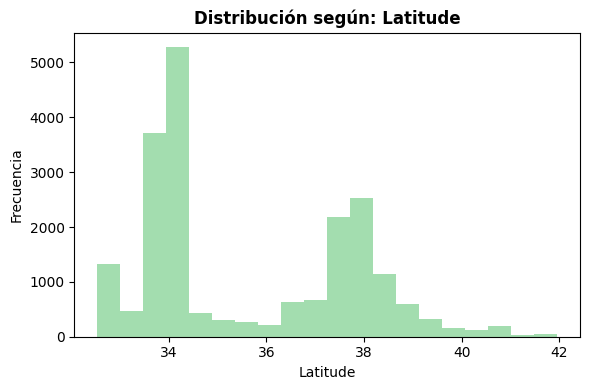

--- Latitude ---
Latitude
34.06    244
34.05    236
34.08    234
34.07    231
34.04    221
        ... 
35.69      1
35.86      1
35.85      1
35.89      1
35.88      1
Name: count, Length: 862, dtype: int64




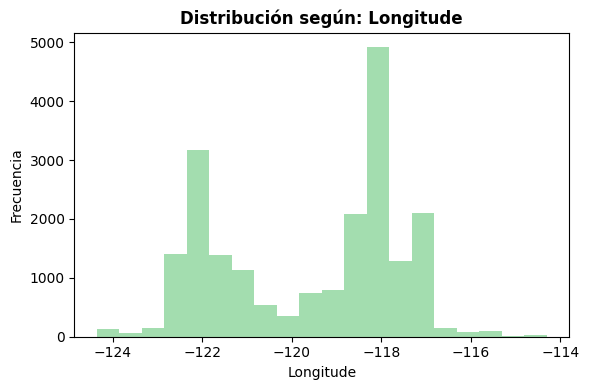

--- Longitude ---
Longitude
-118.31    162
-118.30    160
-118.29    148
-118.27    144
-118.32    142
          ... 
-116.08      1
-115.22      1
-114.67      1
-114.49      1
-116.78      1
Name: count, Length: 844, dtype: int64




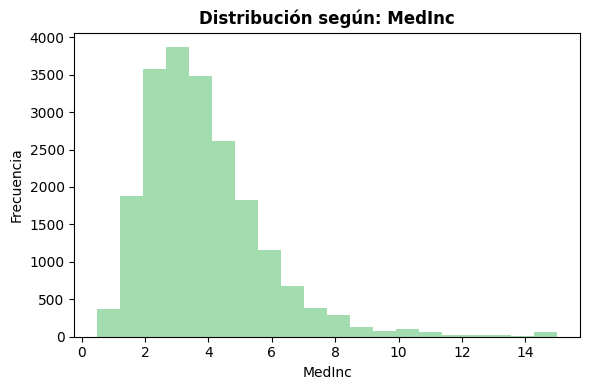

--- MedInc ---
MedInc
15.0001    49
3.1250     49
2.8750     46
4.1250     44
2.6250     44
           ..
4.1292      1
4.4539      1
4.0219      1
4.0687      1
5.2034      1
Name: count, Length: 12928, dtype: int64




In [57]:
#Graficamos los valores que son del tipo -numérico- para visualizar su distribución
num_cols = df.select_dtypes(include="number").columns

for col in num_cols:
    plt.figure(figsize=(6, 4))
    plt.hist(df[col], bins=20, color="#7CCF8E", alpha=0.7)
    plt.title(f"Distribución según: {col}", fontsize=12, fontweight="bold")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()
        
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print("\n")

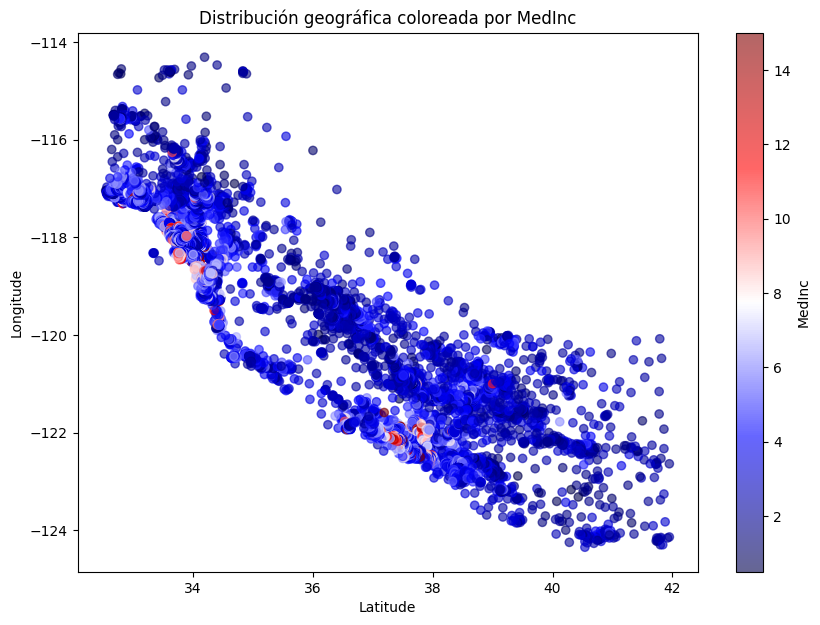

In [58]:
#Graficamos distribución
plt.figure(figsize=(10, 7))
scatter = plt.scatter(df["Latitude"], df["Longitude"], c=df["MedInc"], cmap="seismic", alpha=0.6)

plt.xlabel("Latitude")
plt.ylabel("Longitude")
plt.title("Distribución geográfica coloreada por MedInc")

cbar = plt.colorbar(scatter)
cbar.set_label("MedInc")

plt.show()

In [59]:
train, test = train_test_split(df, test_size=0.1, random_state=42)

In [60]:
#División de train y test
X = df[["Latitude", "Longitude", "MedInc"]]
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

#Escalado de train y test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Dimensiones train:", X_train.shape)
print("Dimensiones test:", X_test.shape)

Dimensiones train: (16512, 3)
Dimensiones test: (4128, 3)


In [61]:
#Modelado K-means
model = KMeans(n_clusters= 6, random_state=42)
model.fit(train)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",6
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [62]:
centroids = model.cluster_centers_
labels = model.labels_

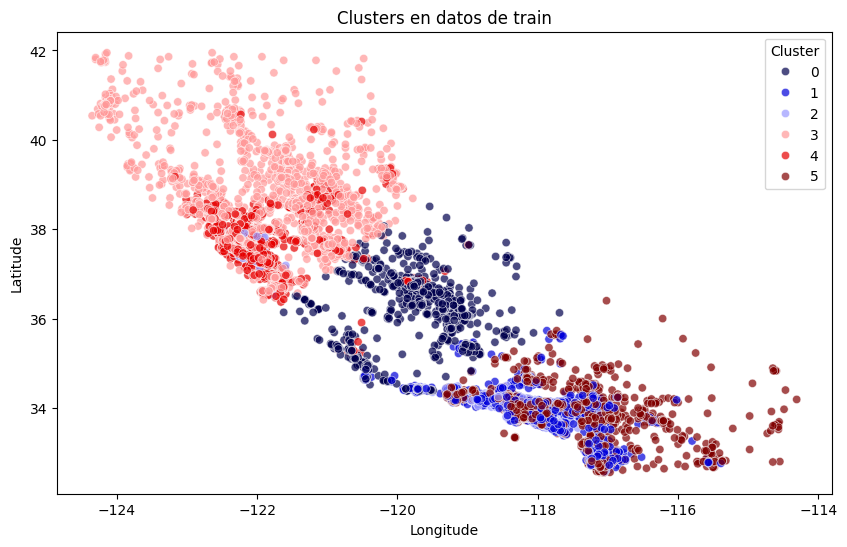

In [63]:
#Graficamos distribución tras K-Means
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
kmeans.fit(X_train_scaled)

#Añadimos cluster
X_train = X_train.copy()
X_train['cluster'] = kmeans.labels_

#Gráficamos train
plt.figure(figsize=(10, 6))
sns.scatterplot(x="Longitude", y="Latitude", hue="cluster", data=X_train, palette="seismic", alpha=0.7)
plt.title("Clusters en datos de train")
plt.legend(title="Cluster")
plt.show()

In [64]:
#Con silhouette vemos la separacion entre los clusters
sil_score = silhouette_score(X_train_scaled, kmeans.labels_)
print(f"Silhouette Score: {sil_score:.3f}")

Silhouette Score: 0.399


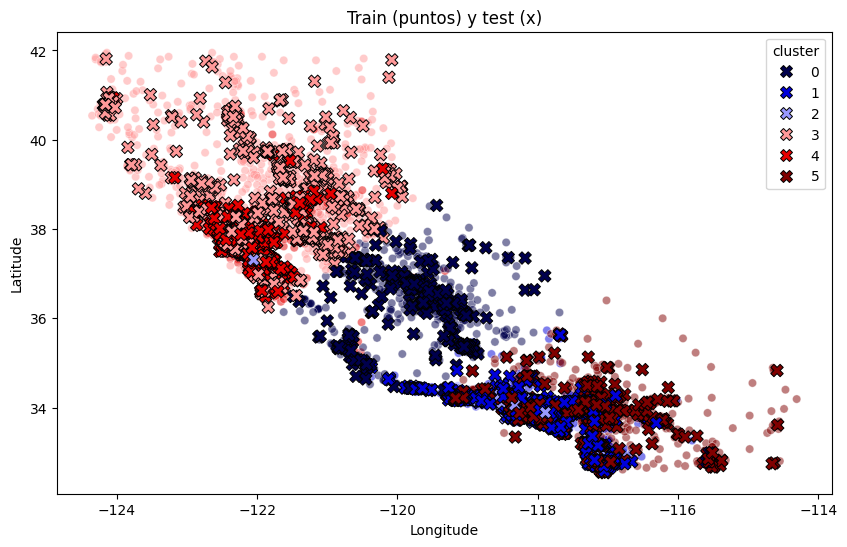

In [65]:
#Graficamos predicción test
X_test = X_test.copy()
X_test["cluster"] = kmeans.predict(X_test_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x="Longitude", y="Latitude", hue="cluster", data=X_train, palette="seismic", alpha=0.5, legend=False)
sns.scatterplot(x="Longitude", y="Latitude", hue="cluster", data=X_test, palette="seismic", marker='X', s=80, edgecolor="k")
plt.title("Train (puntos) y test (x)")
plt.show()

In [66]:
# Preparación
y_train = X_train["cluster"]
y_test = X_test["cluster"]
X_train_sup = X_train.drop("cluster", axis=1)
X_test_sup = X_test.drop("cluster", axis=1)

# Función de evaluación reutilizable
def evaluate_model(model, X_train, X_test, y_train, y_test, name="Modelo"):
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    print(f"\n=== {name} ===")
    print(f"Accuracy → Train: {train_acc:.4f} | Test: {test_acc:.4f}")
    print(classification_report(y_test, model.predict(X_test)))
    return test_acc

# Entrenamiento
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_sup, y_train)

# Evaluación
evaluate_model(rf, X_train_sup, X_test_sup, y_train, y_test, "RF Clasificador")


=== RF Clasificador ===
Accuracy → Train: 1.0000 | Test: 0.9952
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       337
           1       1.00      1.00      1.00       829
           2       1.00      0.98      0.99       112
           3       0.99      0.99      0.99       962
           4       0.99      1.00      0.99       514
           5       1.00      1.00      1.00      1374

    accuracy                           1.00      4128
   macro avg       0.99      0.99      0.99      4128
weighted avg       1.00      1.00      1.00      4128



0.9951550387596899

Importancia de variables:
MedInc       0.4743
Latitude     0.2697
Longitude    0.2560
dtype: float64


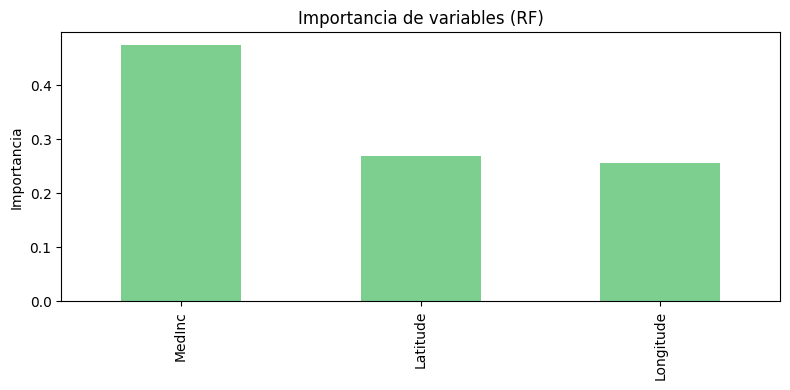

In [67]:
# Importancia de variables
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=X_train_sup.columns).sort_values(ascending=False)
print("Importancia de variables:")
print(feat_imp.round(4))

plt.figure(figsize=(8, 4))
feat_imp.plot(kind='bar', color="#7CCF8E")
plt.title('Importancia de variables (RF)')
plt.ylabel("Importancia")
plt.tight_layout()
plt.show()


In [69]:
#Guardamos modelos
joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(rf, "rf_classifier.pkl")
print("Modelos guardados")

Modelos guardados
